## Исследование датасета для проекта «Ценообразование жилой недвижимости с использованием методов машинного обучения на данных ЦИАН»

In [47]:
try:
    import gdown
except ImportError:
    !pip install gdown
    import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy import stats

## Алия

### 0. Описание данных

* **Количественные признаки:**
  - *price* (целевая переменная) — цена объекта
  - *total_area* – общая площадь
  - *living_area* – жилая площадь
  - *kitchen_area* – площадь кухни
  - *ceiling_height* – высота потолков
  - *floor* – этаж
  - *total_floors* – общее количество этажей
  - *combined_bathroom* – кол-во совмещенных санузлов
  - *separated_bathroom* – кол-во раздельных санузлов
  - *balcony* – кол-во балконов
  - *loggia* – кол-во лоджий
  - *year_of_construction* – год постройки `только для вторичек`
  - *passenger_elevator* – кол-во пассажирских лифтов
  - *cargo_elevator* – кол-во грузовых лифтов
  - *entrances* – количество подъездов `только для вторичек`

* **Категориальные признаки:**
  - *house_type* — тип дома (Блочный/Деревянный/Кирпичный/Монолитно-кирпичный/Монолитный/Панельный/Сталинский/NaN)
  - *view_from_the_windows* — вид из окна (Во двор/На улицу/На улицу и двор/NaN)
  - *repair* — ремонт (Без ремонта/Дизайнерский/Евроремонт/Косметический/NaN) `только для вторичек`
  - *heating* — отопление (Автономная котельная/Индивидуальный тепловой пункт/(Котел/Квартирное отопление)/Нет/Нет информации/Центральное/Электрическое/NaN) `только для вторичек`
  - *parking* — парковка (Многоуровневая/На крыше/Наземная/Открытая/Подземная/NaN)
  - *gas_supply* — газоснабжение (Автономное/Центральное/NaN) `только для вторичек`
  - *apartment* — Апартаменты/Пентхаус/NaN
  - *floor_type* — тип перекрытий (Деревянные/Железобетонные/Смешанные/NaN) `только для вторичек`
  - *finishing* — тип отделки (Без отделки/Нет информации/Под ключ/Предчистовая/С отделкой/Черновая/Чистовая/Чистовая с мебелью/NaN) `только для новостроек`
  - *rooms_count* — формально числовой, но содержит значения "Студия", "Доля", поэтому пока считаем категориальным.

* **Бинарные признаки:**
  - *auction* — аукцион? (в датасете только "Н")
  - *new_biilding* — тип квартиры (Новостройка/Вторичка)
  - *garbage_chute* — мусоропровод (Д/NaN)
  - *concierge* — консьерж (Д/NaN)
  - *accident_rate* — аварийность (Д/Н/NaN) `только для вторичек`
  - *sold_with_furniture* — продается вместе с мебелью (Д/NaN) `только для вторичек`
  - *minor_owners* — несовершеннолетние собственники (Д/Н/NaN)
  - *maternity_capital* — использовался ли маткапитал при покупке (Д/Н/NaN)
  - *ramp* — пандус (Д/NaN) `только для новостроек`

* **Дата и время:**
  - *publication_date* — дата публикации объявления
  - *request_time* — дата парсинга данных объявления

* **Геоданные:**
  - *lat* — широта
  - *lng* — долгота

* **Текстовые (смешанные) данные:**
  - *url* — url объявления
  - *address* — полный адрес объекта
  - *construction_series* — строительная серия `только для вторичек`
  - *metro_info* — информация о ближайших метро (возможно, имеет смысл вычленить только ближайшее метро и время до него, в списке стоит первым)
  - *highway_info* — информация о ближайших дорогах `только для вторичек`
  - *description* — описание объекта, которое заполняется продавцом
  - *seller* — застройщик `только для новостроек`
  - *photos_url* — 15 ссылок на фотографии из объявлений

In [1]:
#при запуске в первый раз скачает файл в директорию этого ноутбука
#файл слишком большой, поэтому при попытке открытия его просто по ссылке гугл выдает ошибку
#поэтому нужна доп библиотека down

link = 'https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l'
output_file = 'cian_full_data.csv'

if not os.path.exists(output_file):
    gdown.download(link, output_file, quiet=False, fuzzy=True)

df = pd.read_csv(output_file, low_memory=False, encoding='utf-8-sig', sep=';')

df.head(5)

Downloading...
From (original): https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l
From (redirected): https://drive.google.com/uc?id=1TgqL2u4rpwNORJ1yhjam9eVzl5-tTM5l&confirm=t&uuid=25dc9e70-e48d-4227-952f-d9f059195150
To: /content/cian_full_data.csv
100%|██████████| 241M/241M [00:03<00:00, 72.5MB/s]


,url,address,price,auction,rooms_count,new_building,apartment,total_area,living_area,kitchen_area,...,lat,lng,minor_owners,maternity_capital,publication_date,request_time,photos_url,seller,finishing,ramp
0,https://www.cian.ru/sale/flat/324994191/,"Москва, ЮАО, р-н Даниловский, м. Автозаводская...",5350000,Н,Студия,Вторичка,Апартаменты,16.0,10.0,5.0,...,55.703885,37.652768,Н,Н,2025-12-19 12:29:00,2025-12-20 03:40:29,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
1,https://www.cian.ru/sale/flat/320317503/,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",5990000,Н,Студия,Вторичка,Апартаменты,16.0,13.5,NaN,...,55.859322,37.515874,NaN,NaN,2025-12-19 16:25:00,2025-12-20 03:40:32,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
2,https://www.cian.ru/sale/flat/322151830/,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",5990000,Н,Студия,Вторичка,Апартаменты,15.2,12.7,NaN,...,55.859322,37.515874,NaN,NaN,2025-12-19 19:55:00,2025-12-20 03:40:38,https://images.cdn-cian.ru/images/kvartira-mos...,NaN,NaN,NaN
3,https://www.cian.ru/sale/flat/323600775/,"Москва, ТАО (Троицкий), пос. Рогово, улица Шко...",5500000,Н,1,Вторичка,NaN,32.6,NaN,7.5,...,55.212647,37.072573,NaN,NaN,2025-12-19 18:22:00,2025-12-20 03:40:41,https://images.cdn-cian.ru/images/2690280423-1...,NaN,NaN,NaN
4,https://www.cian.ru/sale/flat/324712040/,"Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, П...",5600000,Н,Студия,Вторичка,NaN,20.0,12.0,3.0,...,55.704996,37.922335,NaN,NaN,2025-12-18 18:26:00,2025-12-20 03:40:44,https://images.cdn-cian.ru/images/2725644747-1...,NaN,NaN,NaN


Типы данных

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63365 entries, 0 to 63364
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   url                    63365 non-null  object 
 1   address                63365 non-null  object 
 2   price                  63365 non-null  int64  
 3   auction                63365 non-null  object 
 4   rooms_count            63365 non-null  object 
 5   new_building           63365 non-null  object 
 6   apartment              7367 non-null   object 
 7   total_area             63365 non-null  float64
 8   living_area            47957 non-null  float64
 9   kitchen_area           51724 non-null  float64
 10  ceiling_height         49867 non-null  float64
 11  floor                  63365 non-null  int64  
 12  total_floors           63365 non-null  int64  
 13  combined_bathroom      36205 non-null  float64
 14  separated_bathroom     19966 non-null  float64
 15  ba

### 1. Изучение пропусков

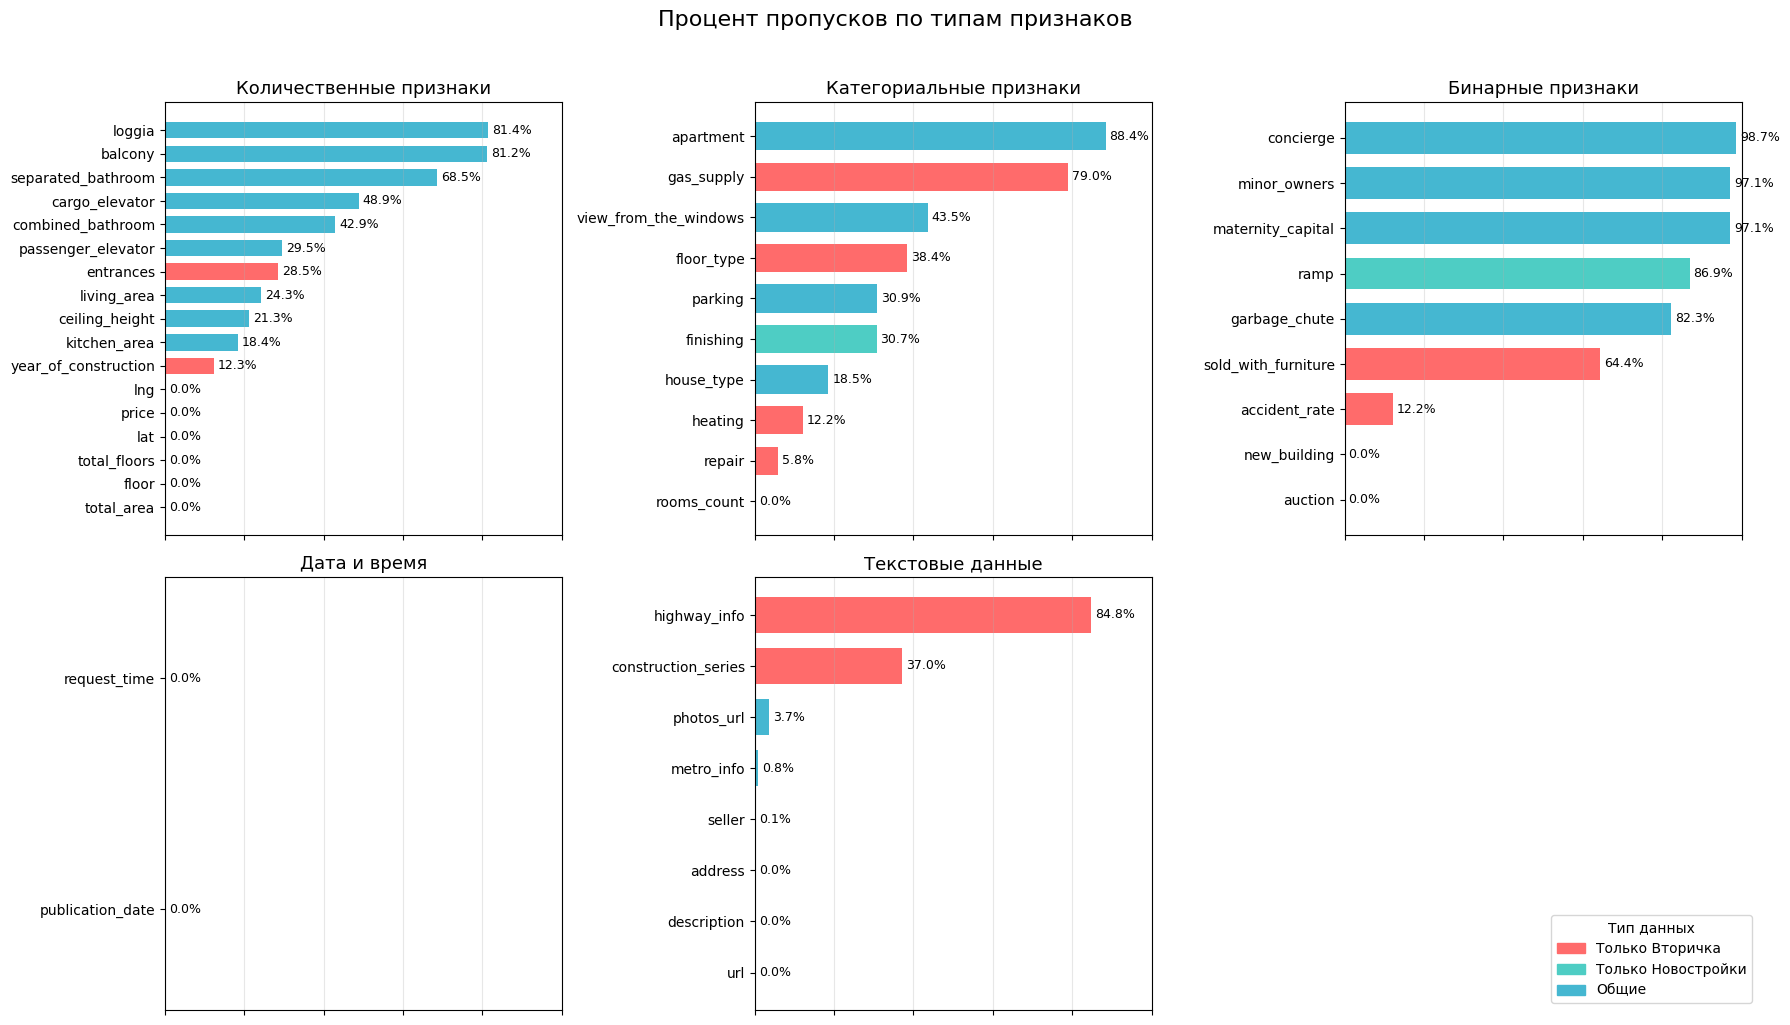

In [17]:
# Разделим датасет на два
only_new = df['new_building'] == 'Новостройка'
only_sec = df['new_building'] == 'Вторичка'

# Считаем долю пропусков
miss_all = df.isna().mean() * 100
miss_new = df[only_new].isna().mean() * 100
miss_sec = df[only_sec].isna().mean() * 100

# Определяем столбцы, которые заполнены только для новостроек
cols_new = miss_sec[miss_sec == 100].index.tolist()
# Только во вторичках
cols_sec = miss_new[miss_new == 100].index.tolist()
# Общие столбцы
cols_common = [c for c in df.columns if c not in cols_new + cols_sec]

# Создаем словарь для классификации признаков
quantitative = ['price', 'total_area', 'living_area', 'kitchen_area', 'ceiling_height',
                'floor', 'total_floors', 'combined_bathroom', 'separated_bathroom',
                'balcony', 'loggia', 'year_of_construction', 'passenger_elevator',
                'cargo_elevator', 'entrances', 'lat', 'lng']

categorical = ['house_type', 'view_from_the_windows', 'repair', 'heating', 'parking',
               'gas_supply', 'apartment', 'floor_type', 'finishing', 'rooms_count']

binary = ['auction', 'new_building', 'garbage_chute', 'concierge', 'accident_rate',
          'sold_with_furniture', 'minor_owners', 'maternity_capital', 'ramp']

datetime = ['publication_date', 'request_time']

text = ['url', 'address', 'construction_series', 'metro_info', 'highway_info',
        'description', 'seller', 'photos_url']

# Функция для подготовки данных для графика
def prepare_data_for_plot(feature_list):
    plot_data = []

    for col in feature_list:
        if col in cols_sec:
            plot_data.append({
                'Column': col,
                'Missing %': miss_sec[col],
                'Group': 'Только Вторичка'
            })
        elif col in cols_new:
            plot_data.append({
                'Column': col,
                'Missing %': miss_new[col],
                'Group': 'Только Новостройки'
            })
        elif col in cols_common:
            plot_data.append({
                'Column': col,
                'Missing %': miss_all[col],
                'Group': 'Общие'
            })

    df_plot = pd.DataFrame(plot_data).sort_values('Missing %', ascending=False)
    return df_plot

# Подготавливаем данные для каждого типа признаков
data_quantitative = prepare_data_for_plot(quantitative)
data_categorical = prepare_data_for_plot(categorical)
data_binary = prepare_data_for_plot(binary)
data_datetime = prepare_data_for_plot(datetime)
data_text = prepare_data_for_plot(text)

# Создаем сабплоты
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Цвета для групп
colors = {'Только Вторичка': '#FF6B6B',
          'Только Новостройки': '#4ECDC4',
          'Общие': '#45B7D1'}

# Функция для построения одного графика
def plot_bars(ax, data, title):
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center')
        ax.set_title(title)
        return

    # Сортируем данные по проценту пропусков (от большего к меньшему)
    data = data.sort_values('Missing %', ascending=True)

    # Создаем список цветов для каждого столбца
    bar_colors = []
    for _, row in data.iterrows():
        bar_colors.append(colors[row['Group']])

    # Рисуем все бары сразу с соответствующими цветами
    bars = ax.barh(data['Column'], data['Missing %'],
                   color=bar_colors, height=0.7)

    ax.set_title(title, fontsize=13)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_xticklabels([])  # Убираем подписи по оси X
    ax.set_xlabel('')  # Убираем label оси X

    # Добавляем подписи процентов на барах
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                va='center', ha='left', fontsize=9)

# Построение графиков
plot_bars(axes[0], data_quantitative, 'Количественные признаки')
plot_bars(axes[1], data_categorical, 'Категориальные признаки')
plot_bars(axes[2], data_binary, 'Бинарные признаки')
plot_bars(axes[3], data_datetime, 'Дата и время')
plot_bars(axes[4], data_text, 'Текстовые данные')

# Удаляем лишний субплот (6-й)
axes[5].axis('off')

# Добавляем общую легенду
handles = [plt.Rectangle((0,0),1,1, color=colors[group]) for group in colors]
labels = list(colors.keys())
fig.legend(handles, labels, title='Тип данных',
           loc='lower right', bbox_to_anchor=(0.98, 0.02))

plt.suptitle('Процент пропусков по типам признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Таблица распределения пропусков по типам признаков

| Уровень пропусков | Количественные признаки | Категориальные признаки | Бинарные признаки | Текстовые данные | Дата/время |
|-------------------|-------------------------|-------------------------|-------------------|------------------|------------|
| **Очень высокий (>80%)** | `loggia` (81.4%)<br><br>`balcony` (81.2%) | `apartment` (88.4%) | `concierge` (98.7%)<br><br>`minor_owners` (97.1%)<br><br>`maternity_capital` (97.1%)<br><br>`ramp` (86.9%)<br><br>`garbage_chute` (82.3%) | `highway_info` (84.8%) | - |
| **Высокий (40-80%)** | `separated_bathroom` (68.5%)<br><br>`cargo_elevator` (48.9%)<br><br>`combined_bathroom` (42.9%) | `gas_supply` (79.0%)<br><br>`view_from_the_windows` (43.5%) | `sold_with_furniture` (64.4%) | - | - |
| **Средний (20-40%)** | `passenger_elevator` (29.5%)<br><br>`entrances` (28.5%)<br><br>`living_area` (24.3%)<br><br>`ceiling_height` (21.3%) | `floor_type` (38.4%)<br><br>`parking` (30.9%)<br><br>`finishing` (30.7%) | - | `construction_series` (37.0%) | - |
| **Низкий (1-20%)** | `kitchen_area` (18.4%)<br><br>`year_of_construction` (12.3%) | `house_type` (18.5%)<br><br>`heating` (12.2%)<br><br>`repair` (5.8%) | `accident_rate` (12.2%) | `photos_url` (3.7%)<br><br>`metro_info` (0.8%)<br><br>`seller` (0.1%) | - |
| **Без пропусков (0%)** | `price`<br><br>`lat` (геоданные)<br><br>`lng` (геоданные)<br><br>`total_floors`<br><br>`floor`<br><br>`total_area` | `rooms_count` | `new_building`<br><br>`auction` | `address`<br><br>`description`<br><br>`url` | `request_time`<br><br>`publication_date` |


В датасете наблюдается неравномерное распределение пропусков, которое объясняется логикой предметной области, а не проблемами сбора данных

Рекомендации по обработке:
1. **Бинарные признаки** с высокими пропусками можно заполнить значением 0/"Нет"
2. **Категориальные признаки** рассмотреть возможность введения категории "не указано"
3. и т.д.
4. **Основные признаки** (`price`,`lat`, `lng`, `publication_date`,`total_area`, `floor`, `total_floors`, `rooms_count`, `address`) для моделирования доступны полностью — можно строить модели без критичных потерь данных


Стратегия обработки данных будет принята в дальнейшей, когда будет принято решение о перечне используемых параметров для модели

# Андрей

### Исследуем соответствуют ли типы данных в датасете необходимым.

In [18]:
def overview(df):
    exclude_cols = ['url', 'description', 'photos_url', 'index', 'price']
    text_df = df.select_dtypes(include = ['object', 'string'])
    cols_to_analyze = [c for c in text_df.columns if c not in exclude_cols]

    fin_df = []
    total_rows = len(df)

    for col in cols_to_analyze:
        col_series = df[col]
        unique_values = col_series.dropna().unique()

        n_nan = col_series.isna().sum()
        n_filled = total_rows - n_nan
        n_unique = len(unique_values)
        zap = (n_unique/n_filled*100) if n_filled > 0 else 0

        examples = list(unique_values[:5])
        examples_str = " || ".join(map(str, examples))

        fin_df.append({"Признак": col,
            "Заполнено": n_filled,
            "Пропущено": n_nan,
            "Уникальных": n_unique,
            "Разнообразие в проц": round(zap, 2),
            "Примеры": examples_str})

    return pd.DataFrame(fin_df).set_index("Признак")

In [19]:
overview(df)

,Заполнено,Пропущено,Уникальных,Разнообразие в проц,Примеры
Признак,,,,,
address,63365,0,16511,26.06,"Москва, ЮАО, р-н Даниловский, м. Автозаводская..."
auction,63365,0,1,0.00,Н
rooms_count,63365,0,9,0.01,Студия || 1 || 2 || 3 || Доля
new_building,63365,0,2,0.00,Вторичка || Новостройка
apartment,7367,55998,2,0.03,Апартаменты || Пентхаус
view_from_the_windows,35772,27593,3,0.01,Во двор || На улицу || На улицу и двор
repair,35322,28043,4,0.01,Евроремонт || Косметический || Без ремонта || ...
construction_series,23607,39758,96,0.41,Индивидуальный проект || П-3М || 1-511 || ГМС-...
floor_type,23102,40263,3,0.01,Железобетонные || Деревянные || Смешанные


Как видим, некоторые признаки имеют излишнюю уникальность, которая может негативно повлиять на точность модели.
В нашем случае очевидно, что признаки:

1.   metro_info
2.   highway_info
3.   seller
4.   address

могут быть разбиты на несколько признаков, объекты которых будут значительно более подходящими для категориальных признаков по характеру значений - количество уникальных значений будет значительно меньшим, а также некоторые признаки выделенные будут числовыми - к примеру, расстояние до ближайшего шоссе или метро.

Начнем с анализа содержимого адреса.

In [20]:
df.address.unique()[:30]

array(['Москва, ЮАО, р-н Даниловский, м. Автозаводская, Автозаводская улица, 19К1',
       'Москва, САО, р-н Головинский, м. Моссельмаш, Сенежская улица, 3',
       'Москва, ТАО (Троицкий), пос. Рогово, улица Школьная, 17',
       'Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, Покровская улица, 31',
       'Москва, ТАО (Троицкий), пос. ЛМС, Центральный мкр, 7',
       'Москва, ВАО, р-н Измайлово, м. Измайловская, 4-я Парковая улица, 24',
       'Москва, ТАО (Троицкий), м. Троицк, с. Былово, Былово кп, улица Радужная, 2',
       'Москва, САО, р-н Ховрино, м. Грачёвская, Клинская улица, 8С1',
       'Москва, ТАО (Троицкий), Витро Вилладж База отдыха, к4',
       'Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, Рождественская улица, 21к5',
       'Москва, ТАО (Троицкий), Витро Вилладж База отдыха, к7',
       'Москва, ТАО (Троицкий), м. Троицк, Троицк, улица Городская, 20',
       'Москва, ВАО, р-н Преображенское, м. Электрозаводская, 1-й Электрозаводский переулок, 4',
       'Москва, ТАО (Тр

Очевидно логично выделить из адреса три признака: метро указанное в адресе, округ и район. Число уникальных объектов в данных признаках будет достаточно малым.

In [21]:
def parse_address(addr):
    if not isinstance(addr, str):
        return pd.Series([np.nan, np.nan, np.nan])

    s = addr.lower()

    okrug = np.nan
    district = np.nan
    metro = np.nan

    parts = [p.strip() for p in s.split(",")]

    if len(parts) > 1:
        okrug = parts[1]

    for p in parts:
        if p.startswith("р-н"):
            district = p
        elif p.startswith("м."):
            metro = p.replace("м.", "").strip()

    return pd.Series([okrug, district, metro])

In [22]:
df[["okrug", "district", "metro_adress"]] = df["address"].apply(parse_address)

In [23]:
df[["address","okrug", "district", "metro_adress"]].head(10)

,address,okrug,district,metro_adress
0,"Москва, ЮАО, р-н Даниловский, м. Автозаводская...",юао,р-н даниловский,автозаводская
1,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",сао,р-н головинский,моссельмаш
2,"Москва, САО, р-н Головинский, м. Моссельмаш, С...",сао,р-н головинский,моссельмаш
3,"Москва, ТАО (Троицкий), пос. Рогово, улица Шко...",тао (троицкий),NaN,NaN
4,"Москва, ЮВАО, р-н Некрасовка, м. Некрасовка, П...",ювао,р-н некрасовка,некрасовка
5,"Москва, ТАО (Троицкий), пос. ЛМС, Центральный ...",тао (троицкий),NaN,NaN
6,"Москва, ВАО, р-н Измайлово, м. Измайловская, 4...",вао,р-н измайлово,измайловская
7,"Москва, ТАО (Троицкий), м. Троицк, с. Былово, ...",тао (троицкий),NaN,троицк
8,"Москва, САО, р-н Ховрино, м. Грачёвская, Клинс...",сао,р-н ховрино,грачёвская
9,"Москва, ТАО (Троицкий), Витро Вилладж База отд...",тао (троицкий),NaN,NaN


Продолжим. Разделим признак продавца на новые признаки: тип продавца и уникальное имя.

In [24]:
df.seller.unique()

array([nan, 'Агентство недвижимости, Ордер',
       'Автор объявления, ID 135186715', ...,
       'Автор объявления, Ирина Иванова',
       'Агентство недвижимости, New Day Realty',
       'Автор объявления, Владислав Дворов'], dtype=object)

In [25]:
def parse_seller(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None])
    parts = cell.split(",", 1)
    seller_type = parts[0].strip()
    seller_name = parts[1].strip() if len(parts)>1 else None
    return pd.Series([seller_type, seller_name])

df[["seller_type", "seller_name"]] = df["seller"].apply(parse_seller)

In [26]:
df[["seller","seller_type", "seller_name"]].dropna().head(5)

,seller,seller_type,seller_name
37499,"Агентство недвижимости, Ордер",Агентство недвижимости,Ордер
37500,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37501,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37502,"Автор объявления, ID 135186715",Автор объявления,ID 135186715
37503,"Автор объявления, ID 135186715",Автор объявления,ID 135186715


Просмотрим подробнее информацию о метро

In [27]:
df["metro_info"].head(10)

,metro_info
0,"Автозаводская 5 мин. (пешком), ЗИЛ 9 мин. (пеш..."
1,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин..."
2,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин..."
3,NaN
4,"Некрасовка 3 мин. (пешком), Лухмановская 18 ми..."
5,NaN
6,"Измайловская 12 мин. (пешком), Первомайская 12..."
7,"Троицк откроется в 2026 15 мин. (на машине), В..."
8,"Беломорская 18 мин. (пешком), Грачёвская 11 ми..."
9,NaN


Разобьем информацию о метро по аналогии на признаки: количество станций поблизости, ближайшая по скорости дороги, как добраться до ближайшей - на машине или пешком, и открыта ли ближайшая.

In [30]:
def parse_transport(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None, None, 0, "нет"])

    pattern = r"(.+?)\s+(\d+)\s+мин\.\s+\((пешком|на машине)\)"
    matches = re.findall(pattern, cell)

    if not matches:
        return pd.Series([None, None, None, 0, "нет"])

    st, mins, mode = matches[0]

    st_name = st.strip().strip(", ")

    if "откроется в" in st_name:
        st_name = re.split(r"\s*откроется в\s*.*", st_name)[0].strip(", ")
        nearest_station_open = "нет"
    else:
        nearest_station_open = "да"

    return pd.Series([mode,
        int(mins),
        st_name,
        len(matches),
        nearest_station_open])

df[["fastest_mode",
    "fastest_minutes",
    "nearest_station",
    "stations_nearby",
    "nearest_station_open"]] = df["metro_info"].apply(parse_transport)


In [31]:
df[[ "metro_info",
    "fastest_mode",
    "fastest_minutes",
    "nearest_station",
    "stations_nearby",
    "nearest_station_open"]].dropna().head(5)

,metro_info,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open
0,"Автозаводская 5 мин. (пешком), ЗИЛ 9 мин. (пеш...",пешком,5.0,Автозаводская,3,да
1,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...",пешком,10.0,Моссельмаш,3,да
2,"Моссельмаш 10 мин. (пешком), Грачёвская 19 мин...",пешком,10.0,Моссельмаш,3,да
4,"Некрасовка 3 мин. (пешком), Лухмановская 18 ми...",пешком,3.0,Некрасовка,3,да
6,"Измайловская 12 мин. (пешком), Первомайская 12...",пешком,12.0,Измайловская,3,да


Закончим выделение признаков в более дискретные или числовые на разделении информации о шоссе поблизости: выделим в числовую переменную расстояние до мкада, название ближайшего шоссе и количество шоссе поблизости.

In [32]:
def parse_roads(cell):
    if not isinstance(cell, str) or cell.strip() == "":
        return pd.Series([None, None, 0])

    pattern = r"([^,]+?)(?:,\s*(\d+)\s*км от МКАД)?(?=,|$)"
    matches = re.findall(pattern, cell)

    roads = []
    for rd, km in matches:
        rd_name = rd.strip()
        km_v = int(km) if km else None
        roads.append((rd_name, km_v))

    if not roads:
        return pd.Series([None, None, 0])

    roads_w_km = [r for r in roads if r[1] is not None]
    if roads_w_km:
        nrst = min(roads_w_km, key=lambda x: x[1])
        nrst_name = nrst[0]
        nrst_km = nrst[1]
    else:
        nrst_name = roads[0][0]
        nrst_km = None

    return pd.Series([nrst_name, nrst_km, len(roads)])

In [33]:
df[["nearest_road", "distance_from_mkad", "roads_nearby_count"]] = df["highway_info"].apply(parse_roads)

In [34]:
df["nearest_road"].unique()

array([nan, 'Калужское шоссе', 'Косинское шоссе', 'Варшавское шоссе',
       'Пятницкое шоссе', 'Дмитровское шоссе', 'Ленинградское шоссе',
       'Киевское шоссе', 'Новорижское шоссе', 'Сколковское шоссе',
       'Боровское шоссе', 'Носовихинское шоссе', 'Минское шоссе',
       'Куркинское шоссе', 'Щелковское шоссе', 'Алтуфьевское шоссе',
       'Волоколамское шоссе', 'Симферопольское шоссе',
       'Ярославское шоссе', 'Новорязанское шоссе', 'Рязанское шоссе',
       'Новоегорьевское шоссе', 'Каширское шоссе', 'Осташковское шоссе',
       'Каспий шоссе', 'Новосходненское шоссе', 'Можайское шоссе',
       'Рублевское шоссе', 'M-11 шоссе', 'Машкинское шоссе',
       'Рублево-Успенское шоссе'], dtype=object)

In [35]:
df[["distance_from_mkad", "nearest_road"]].dropna().head()

,distance_from_mkad,nearest_road
3,59.0,Калужское шоссе
4,5.0,Косинское шоссе
5,42.0,Калужское шоссе
7,27.0,Калужское шоссе
9,34.0,Варшавское шоссе


Приведем текстовые данные к стандартному формату.

In [36]:
def clean_text(cell):
    if not isinstance(cell, str):
        return cell
    cell = cell.strip()
    cell = cell.strip(" ")
    cell = cell.strip(",")
    cell = cell.lower()
    return cell

for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].apply(clean_text)

### Посчитаем описательные статистики

Так как задание не конкретизировано, выделим следующие описательные статистики - число и для числовых признаков:



1.   Доля_пропущенных

1.   Среднее

1.   Медиана

1.   Мода
2.   Отклонение (стандартное)


2.   Дисперсия


2.   Минимум


2.   Максимум


2.   Разброс минимума с максимумом (Разброс_мин_макс)


1.   Квантиль_25

1.   Квантиль_75

1.   Межквантильный_размах
2.   Коэффициент_вариации


2.   Ассиметрия


2.   Эксцесс

Для категориальных данных существует меньше статистик, выбраны следующие:


1.   Доля_пропущенных

1.   Доля_уникальных (из заполненных)
2.   Мода
3.   Доля_самого_частого_значения



In [37]:
def get_complete_stats(df):
    num_df = df.select_dtypes(include = [np.number])
    cat_df = df.select_dtypes(exclude = [np.number])
    total_rows = len(df)

    num_stats = pd.DataFrame()
    if len(num_df.columns) > 0:
        num_stats["Доля_пропущенных"] = num_df.isna().sum()/total_rows
        num_stats["Среднее"] = num_df.mean()
        num_stats["Медиана"] = num_df.median()
        try:
            num_stats["Мода"] = num_df.mode().iloc[0]
        except Exception:
            num_stats["Мода"] = np.nan
        num_stats["Отклонение"] = num_df.std()
        num_stats["Дисперсия"] = num_df.var()
        num_stats["Минимум"] = num_df.min()
        num_stats["Максимум"] = num_df.max()
        num_stats["Разброс_мин_макс"] = num_stats["Максимум"] - num_stats["Минимум"]
        num_stats["Квантиль_25"] = num_df.quantile(0.25)
        num_stats["Квантиль_75"] = num_df.quantile(0.75)
        num_stats["Межквартильный размах"] = num_stats["Квантиль_75"] - num_stats["Квантиль_25"]
        num_stats["Коэффициент_вариации"] = num_stats["Отклонение"]/num_stats["Среднее"]
        num_stats["Ассиметрия"] = num_df.skew()
        num_stats["Эксцесс"] = num_df.kurtosis()

    cat_stats = pd.DataFrame()
    if len(cat_df.columns) > 0:
        nan_cnt = cat_df.isna().sum()
        filled_cnt = total_rows - nan_cnt
        cat_stats["Доля_пропущенных"] = nan_cnt/total_rows
        cat_stats["Доля_уникальных"] = cat_df.nunique()/filled_cnt
        try:
            cat_stats["Мода"] = cat_df.mode().iloc[0]
        except Exception:
            cat_stats["Мода"] = np.nan
        top_part = []
        for col in cat_df.columns:
            s = cat_df[col].dropna()
            if len(s) == 0:
                top_part.append(0)
            else:
                top_part.append(s.value_counts(normalize = True).iloc[0])
        cat_stats["Доля_самого_частого_значения"] = top_part

    return num_stats, cat_stats

In [38]:
st=get_complete_stats(df)
pd.options.display.float_format = '{:.3f}'.format
st[0]

,Доля_пропущенных,Среднее,Медиана,Мода,Отклонение,Дисперсия,Минимум,Максимум,Разброс_мин_макс,Квантиль_25,Квантиль_75,Межквартильный размах,Коэффициент_вариации,Ассиметрия,Эксцесс
price,0.000,54197134.574,25000000.000,14500000.000,115573579.624,13357252307166628.000,850000.000,8174870000.000,8174020000.000,16378372.000,45204120.000,28825748.000,2.132,14.260,541.216
total_area,0.000,73.750,60.000,60.000,59.909,3589.054,6.000,4288.000,4282.000,41.800,83.500,41.700,0.812,10.055,435.540
living_area,0.243,39.180,31.400,20.000,34.868,1215.808,0.200,1150.000,1149.800,20.000,46.000,26.000,0.890,6.616,99.454
kitchen_area,0.184,14.350,12.000,10.000,9.577,91.727,0.100,240.000,239.900,8.000,18.400,10.400,0.667,2.766,19.824
ceiling_height,0.213,3.031,3.000,3.000,2.130,4.539,0.000,310.000,310.000,2.730,3.100,0.370,0.703,118.910,16512.116
floor,0.000,11.143,8.000,2.000,10.116,102.334,-2.000,84.000,86.000,4.000,15.000,11.000,0.908,1.939,5.114
total_floors,0.000,21.199,17.000,9.000,14.168,200.740,1.000,97.000,96.000,11.000,27.000,16.000,0.668,1.511,2.911
combined_bathroom,0.429,1.400,1.000,1.000,0.701,0.491,1.000,9.000,8.000,1.000,2.000,1.000,0.501,2.333,8.596
separated_bathroom,0.685,1.201,1.000,1.000,0.549,0.301,1.000,9.000,8.000,1.000,1.000,0.000,0.457,4.073,26.716
balcony,0.812,1.181,1.000,1.000,0.491,0.241,1.000,4.000,3.000,1.000,1.000,0.000,0.415,3.141,10.951


In [39]:
st[1]

,Доля_пропущенных,Доля_уникальных,Мода,Доля_самого_частого_значения
url,0.000,1.000,https://www.cian.ru/sale/flat/150959906/,0.000
address,0.000,0.261,"москва, зао, р-н можайский",0.005
auction,0.000,0.000,н,1.000
rooms_count,0.000,0.000,2,0.318
new_building,0.000,0.000,вторичка,0.592
apartment,0.884,0.000,апартаменты,0.957
view_from_the_windows,0.435,0.000,на улицу и двор,0.402
repair,0.443,0.000,дизайнерский,0.296
construction_series,0.627,0.004,индивидуальный проект,0.682
floor_type,0.635,0.000,железобетонные,0.964


# Кирилл

## Значения признаков

In [40]:
data = df.copy()
data = data.drop(labels=['publication_date','request_time','lat','lng'],axis=1) # не несут в себе никакой смысловой нагрузки для min_max_range

stat = data.describe().T
concated_min_max_df = pd.concat([stat["min"],stat["max"]],axis=1)

pd.set_option('display.float_format', '{:.0f}'.format)
concated_min_max_df

,min,max
price,850000,8174870000
total_area,6,4288
living_area,0,1150
kitchen_area,0,240
ceiling_height,0,310
floor,-2,84
total_floors,1,97
combined_bathroom,1,9
separated_bathroom,1,9
balcony,1,4


In [41]:
dig_columns = set(concated_min_max_df.index.tolist())
all_columns = set(data.columns.tolist())
object_columns = list(all_columns - dig_columns) # узнаём названия не числовых признаков и формируем из них список

In [42]:
data_object_columns = data[object_columns].copy()
data_object_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63365 entries, 0 to 63364
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   seller_type            25847 non-null  object
 1   floor_type             23102 non-null  object
 2   metro_info             62876 non-null  object
 3   parking                43778 non-null  object
 4   sold_with_furniture    13337 non-null  object
 5   okrug                  63350 non-null  object
 6   house_type             51618 non-null  object
 7   gas_supply             7859 non-null   object
 8   accident_rate          32919 non-null  object
 9   finishing              17928 non-null  object
 10  photos_url             61031 non-null  object
 11  nearest_station        37011 non-null  object
 12  construction_series    23607 non-null  object
 13  heating                32919 non-null  object
 14  maternity_capital      1845 non-null   object
 15  minor_owners       

In [43]:
#Избавляюсь от признаков object-typ'а, которые не несут информационной нагрузки для ...
#... выявления категориального диапазона в каждой колонке-признаке. Некоторые признаки...
#... были распарсены на предыдущем этапе EDA (address,metro_info,seller) -> избавляемся.

data_object_columns = data_object_columns.drop(labels=['address','description','url','photos_url','metro_info','seller'],axis=1)

In [44]:
data_object_uniques = data_object_columns.nunique(dropna=True)
data_object_uniques = data_object_uniques.to_frame().rename(columns= {0 : "unique_values"})
data_object_uniques

,unique_values
seller_type,7
floor_type,3
parking,5
sold_with_furniture,1
okrug,272
house_type,7
gas_supply,2
accident_rate,2
finishing,8
nearest_station,326


На количество уникальных значений для каждого рассматриваемого object-type признака датасета посмотрели, теперь выведем их уникальные значения на экран

In [45]:
def get_unique_values(df : pd.DataFrame, column_name : str) -> np.ndarray:
  '''
  Function returns ndarray with unique values from column in pd.DataFrame object

  Args:
    :input: df -> pd.DataFrame object, column_name : str
    :returns: unique_values : np.ndarray
  '''

  data = df.copy()
  unique_values = data[column_name].unique()

  return unique_values

columns_to_collect = data_object_columns.columns.to_list()

for col in columns_to_collect:
  unique_values = get_unique_values(data_object_columns,col)
  print(f"{col}: {unique_values}")

seller_type: [None 'агентство недвижимости' 'автор объявления' 'застройщик'
 'собственник' 'консультант' 'представитель застройщика'
 'управляющая компания']
floor_type: [nan 'железобетонные' 'деревянные' 'смешанные']
parking: [nan 'наземная' 'открытая' 'многоуровневая' 'подземная' 'на крыше']
sold_with_furniture: ['д' nan]
okrug: ['юао' 'сао' 'тао (троицкий)' 'ювао' 'вао' 'сзао' 'зао' 'юзао' 'свао'
 'цао' 'зелао' 'нао (новомосковский)' 'р-н новая москва' 'м. медведково'
 'марьино поселок' 'эвер жилой комплекс' 'столбово деревня'
 'волоколамское ш.' 'скандинавия жилой комплекс'
 'инноватор жилой комплекс' 'автозаводская ул.' 'символ жилой комплекс'
 'левел южнопортовая жилой комплекс' 'ул. гастелло'
 'ул. 4-я марьиной рощи' '№ 103 квартал' 'наб. покровская' '№ 76 квартал'
 'кинематографический квартал' 'рублево-архангельское микрорайон'
 'джойс жилой комплекс' 'варшавское ш.' 'ул. разведчика дейча'
 'волгоградский просп.' 'дзен-кварталы жилой комплекс' 'часовая ул.'
 'пейв жилой компле

## Выбросы

In [48]:
#IQR, Z-Score, quantile

def processing_outliers_iqr(df : pd.DataFrame, column_name : str) -> pd.DataFrame:
  '''
  Function returns pd.DataFrame darray without outliers, calculated by IQR

  Args:
    :input: df -> pd.DataFrame, column_name : str
    :returns: data_wo_outliers : pd.DataFrame
  '''
  data = df.copy()

  Q1 = data[column_name].quantile(0.25)
  Q3 = data[column_name].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - IQR * 1.5
  upper_bound = Q3 + IQR * 1.5

  data_wo_outliers = data[(data[column_name] >= lower_bound) & (data[column_name] <= upper_bound)]

  return data_wo_outliers

def processing_outliers_z_score(df : pd.DataFrame, column_name : str, threshold : int = 3) -> pd.DataFrame:
  '''
  Function returns pd.DataFrame darray without outliers, calculated by Z-Score

  Args:
    :input: df -> pd.DataFrame, column_name : str, threshold : int
    :returns: data_wo_outliers : pd.DataFrame
  '''
  data = df.copy()
  z_scores = np.abs(stats.zscore(data[column_name].dropna()))
  mask = pd.Series(True, index=data.index)

  notna_mask = data[column_name].notna()
  mask[notna_mask] = z_scores < threshold

  data_wo_outliers = data[mask]

  return data_wo_outliers

def processing_outliers_percentile(df : pd.DataFrame, column_name : str, lower_percentile : int = 5, upper_percentile : int = 95) -> pd.DataFrame:
    '''
    Function returns pd.DataFrame darray without outliers, calculated by percentile

    Args:
      :input: df -> pd.DataFrame, column_name : str, lower_percentile : int, upper_percentile : int
      :returns: data_wo_outliers : pd.DataFrame
    '''

    data = df.copy()
    lower_bound = data[column_name].quantile(lower_percentile / 100)
    upper_bound = data[column_name].quantile(upper_percentile / 100)

    data_wo_outliers = data[(data[column_name] >= lower_bound) & (data[column_name] <= upper_bound)]

    return data_wo_outliers

data_iqr = processing_outliers_iqr(data,"price")
df_clean_iqr = data_iqr.dropna(subset=['price'])

data_z_score = processing_outliers_z_score(data,"price")
df_clean_z_score = data_z_score.dropna(subset=['price'])

data_percentile = processing_outliers_percentile(data,"price",1,99)
df_clean_percentile = data_percentile.dropna(subset=['price'])

print(f"orig shape: {data.shape}")
print(f"IQR shape: {df_clean_iqr.shape}")
print(f"Z-Score shape: {df_clean_z_score.shape}")
print(f"Percentile shape: {df_clean_percentile.shape}")
print(f"\nPercentage of IQR outliers: {np.abs((((df_clean_iqr.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")
print(f"Percentage of Z-Score outliers: {np.abs((((df_clean_z_score.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")
print(f"Percentage of Percentile outliers: {np.abs((((df_clean_percentile.shape[0] / data.shape[0]) * 100) - 100)):.2f}%")

orig shape: (63365, 55)
IQR shape: (55794, 55)
Z-Score shape: (62248, 55)
Percentile shape: (62116, 55)

Percentage of IQR outliers: 11.95%
Percentage of Z-Score outliers: 1.76%
Percentage of Percentile outliers: 1.97%


Поиск ошибок в данных (в доработке)

In [49]:
for col in dig_columns:
  error_data = data[col] < 0
  negative_values = data.loc[error_data, col].tolist()
  if negative_values:
    print(negative_values)

[-1, -1, -1, -1, -1, -1, -1, -1, -2]


# Настя

## Матрица корреляции числовых переменных